# Load and preprocess a DICOM series

In [15]:
import os
import numpy as np
import pydicom
import cv2
from tqdm import tqdm

INPUT_DIR = r"D:/Dissertation2/extracted"
OUTPUT_DIR = r"D:/Dissertation2/preprocessed_npyfile"
TARGET_IMAGE_SIZE = (224, 224)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_dicom_series(folder_path):
    """Load and preprocess a DICOM series, returning sorted normalized slices."""
    dicom_files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(".dcm")
    ]

    slices = []
    for file in dicom_files:
        try:
            ds = pydicom.dcmread(file)
            img = ds.pixel_array.astype(np.float32)

            # Normalize to [0, 1]
            img -= np.min(img)
            max_val = np.max(img)
            if max_val > 0:
                img /= max_val

            # Resize only if needed
            if img.shape != TARGET_IMAGE_SIZE:
                img = cv2.resize(img, TARGET_IMAGE_SIZE, interpolation=cv2.INTER_AREA)

            instance_num = getattr(ds, 'InstanceNumber', 0)
            slices.append((img, instance_num))
        except Exception as e:
            print(f"⚠️ Could not read {file}: {e}")
            continue

    # Sort by Instance Number
    slices.sort(key=lambda x: x[1])

    if len(slices) == 0:
        return np.empty((0, *TARGET_IMAGE_SIZE), dtype=np.float32)

    volume = np.stack([s[0] for s in slices], axis=0)

    return volume  # Shape: (num_slices, 224, 224)

# Example: Process all patient folders and save volumes as npy for speed later
for patient_folder in tqdm(os.listdir(INPUT_DIR), desc="Processing patients"):
    patient_path = os.path.join(INPUT_DIR, patient_folder)
    if not os.path.isdir(patient_path):
        continue

    volume = load_dicom_series(patient_path)
    if volume.size == 0:
        print(f"⚠️ No valid slices found for patient {patient_folder}")
        continue

    save_path = os.path.join(OUTPUT_DIR, f"{patient_folder}.npy")
    np.save(save_path, volume)


Processing patients:   6%|███▎                                                      | 28/493 [12:26<4:01:06, 31.11s/it]

⚠️ No valid slices found for patient CQ500-CT-120


Processing patients:  87%|█████████████████████████████████████████████████▋       | 430/493 [5:20:03<54:04, 51.51s/it]C:\Users\irint\AppData\Roaming\Python\Python312\site-packages\pydicom\filereader.py:487: UserWarning: End of file reached before delimiter (FFFE,E0DD) found in file D:/Dissertation2/extracted\CQ500-CT-483\CT000058-CQ500CT483-CQ500CT483-Unknown-Study-CT-Thin-Plain.dcm
  warn_and_log(msg, UserWarning)


⚠️ Could not read D:/Dissertation2/extracted\CQ500-CT-483\CT000058-CQ500CT483-CQ500CT483-Unknown-Study-CT-Thin-Plain.dcm: The dataset has no 'Pixel Data', 'Float Pixel Data' or 'Double Float Pixel Data' element, no pixel data to decode


Processing patients:  98%|███████████████████████████████████████████████████████▋ | 482/493 [5:58:15<10:27, 57.02s/it]C:\Users\irint\AppData\Roaming\Python\Python312\site-packages\pydicom\filereader.py:487: UserWarning: End of file reached before delimiter (FFFE,E0DD) found in file D:/Dissertation2/extracted\CQ500-CT-9\CT000083-CQ500CT9-CQ500CT9-Unknown-Study-CT-Thin-Plain.dcm
  warn_and_log(msg, UserWarning)


⚠️ Could not read D:/Dissertation2/extracted\CQ500-CT-9\CT000083-CQ500CT9-CQ500CT9-Unknown-Study-CT-Thin-Plain.dcm: The dataset has no 'Pixel Data', 'Float Pixel Data' or 'Double Float Pixel Data' element, no pixel data to decode


Processing patients:  99%|████████████████████████████████████████████████████████▌| 489/493 [6:03:25<02:54, 43.55s/it]

⚠️ Could not read D:/Dissertation2/extracted\CQ500-CT-96\CT000003-CQ500CT96-CQ500CT96-Unknown-Study-CT-POST-CONTRAST.dcm: The number of bytes of pixel data is less than expected (482580 vs 524288 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect


Processing patients: 100%|█████████████████████████████████████████████████████████| 493/493 [6:06:31<00:00, 44.61s/it]


# label creation

In [20]:
import pandas as pd

# Load the original label CSV (comma-separated)
input_csv = r"D:/Dissertation2/extracted/radiologist_labels.csv"
df = pd.read_csv(input_csv)

# Rename 'name' column to 'PatientID'
df.rename(columns={'name': 'PatientID'}, inplace=True)

# Strip any whitespace from column names (just in case)
df.columns = df.columns.str.strip()

# Extract relevant ICH columns
df_labels = df[['PatientID', 'R1:ICH', 'R2:ICH', 'R3:ICH']].copy()
df_labels.rename(columns={
    'R1:ICH': 'ICH_R1',
    'R2:ICH': 'ICH_R2',
    'R3:ICH': 'ICH_R3'
}, inplace=True)

# Compute the labels
df_labels['Label_AtLeastOne'] = df_labels[['ICH_R1', 'ICH_R2', 'ICH_R3']].max(axis=1)
df_labels['Label_AtLeastTwo'] = (df_labels[['ICH_R1', 'ICH_R2', 'ICH_R3']].sum(axis=1) >= 2).astype(int)

# Save to CSV
output_csv = r"D:/Dissertation2/processed_labels.csv"
df_labels.to_csv(output_csv, index=False)

print(f"✅ Processed label file created at: {output_csv}")


✅ Processed label file created at: D:/Dissertation2/processed_labels.csv


# Clahe slices

In [21]:
import os
import numpy as np
import cv2
from tqdm import tqdm
import shutil

# Paths - adjust as needed
INPUT_DIR = r"D:/Dissertation2/preprocessed_npyfile"  # Folder with patient .npy volumes
OUTPUT_DIR = r"D:/Dissertation2/cnn_dataset_clahe_slices"  # Output folder for CLAHE slices
LABELS_CSV_PATH = r"D:/Dissertation2/processed_labels.csv"  # CSV with processed labels (PatientID + Label_AtLeastOne/Two)

# CLAHE setup
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Load labels CSV once into a dictionary for fast lookup
import pandas as pd
labels_df = pd.read_csv(LABELS_CSV_PATH)
labels_dict = labels_df.set_index('PatientID').to_dict(orient='index')

os.makedirs(OUTPUT_DIR, exist_ok=True)

def apply_clahe(slice_2d):
    img_uint8 = (slice_2d * 255).astype(np.uint8)
    return clahe.apply(img_uint8)

for filename in tqdm(os.listdir(INPUT_DIR), desc="Processing patients for CLAHE slices"):
    if not filename.endswith('.npy'):
        continue

    patient_id = filename.replace('.npy', '')
    volume_path = os.path.join(INPUT_DIR, filename)
    volume = np.load(volume_path)

    # Skip patients without label
    if patient_id not in labels_dict:
        print(f"⚠️ No label for {patient_id}, skipping")
        continue

    patient_label_info = labels_dict[patient_id]
    label_at_least_one = patient_label_info.get('Label_AtLeastOne', 0)
    label_at_least_two = patient_label_info.get('Label_AtLeastTwo', 0)

    output_patient_dir = os.path.join(OUTPUT_DIR, patient_id)
    os.makedirs(output_patient_dir, exist_ok=True)

    valid_slices = 0
    for i in range(volume.shape[0]):
        slice_2d = volume[i]

        # Skip blank slices
        if np.mean(slice_2d) < 0.01:
            continue

        slice_clahe = apply_clahe(slice_2d)
        slice_filename = f"slice_{i:03d}.npy"
        np.save(os.path.join(output_patient_dir, slice_filename), slice_clahe)
        valid_slices += 1

    if valid_slices == 0:
        print(f"⚠️ No valid slices for {patient_id}, removing folder")
        shutil.rmtree(output_patient_dir)
        continue

    # Save labels for patient in a small txt file (you can customize)
    label_txt_path = os.path.join(output_patient_dir, "label.txt")
    with open(label_txt_path, "w") as f:
        f.write(f"Label_AtLeastOne: {label_at_least_one}\n")
        f.write(f"Label_AtLeastTwo: {label_at_least_two}\n")

print("Step 2 completed: CLAHE slices saved per patient with labels.")


Processing patients for CLAHE slices: 100%|██████████████████████████████████████████| 489/489 [34:16<00:00,  4.21s/it]

Step 2 completed: CLAHE slices saved per patient with labels.


# Feature Extraction + CSV Dataset for Traditional Models

In [25]:
import pandas as pd
from skimage.filters import threshold_otsu


# Paths - adjust as needed
CLAHE_SLICES_DIR = r"D:/Dissertation2/cnn_dataset_clahe_slices"
OUTPUT_CSV = r"D:/Dissertation2/traditional_features.csv"

# Load labels CSV with 'PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo'
labels_csv_path = r"D:/Dissertation2/processed_labels.csv"
labels_df = pd.read_csv(labels_csv_path)
labels_df.set_index('PatientID', inplace=True)

def extract_features_from_slice(slice_np):
    # slice_np is numpy array dtype uint8 from CLAHE output

    # Normalize slice to 0-1 float for consistent feature calculation
    img_norm = slice_np.astype(np.float32) / 255.0

    # 1. Mean intensity
    mean_intensity = np.mean(img_norm)

    # 2. Standard deviation
    std_intensity = np.std(img_norm)

    # 3. Histogram bins (10 bins)
    hist, _ = np.histogram(img_norm, bins=10, range=(0, 1))
    hist = hist.astype(np.float32) / hist.sum()  # normalize histogram

    # 4. Edge count (Canny edges)
    edges = cv2.Canny(slice_np, 100, 200)
    edge_count = np.sum(edges > 0)

    # 5. Otsu threshold area (count pixels above threshold)
    try:
        otsu_thresh = threshold_otsu(img_norm)
        otsu_area = np.sum(img_norm > otsu_thresh)
    except ValueError:
        otsu_area = 0  # fallback for uniform images

    # Combine features into one vector
    features = [mean_intensity, std_intensity, edge_count, otsu_area] + hist.tolist()
    return features

feature_names = ['mean_intensity', 'std_intensity', 'edge_count', 'otsu_area'] + [f'hist_bin_{i}' for i in range(10)]

patient_features_list = []

for patient_id in tqdm(os.listdir(CLAHE_SLICES_DIR), desc="Extracting features"):
    patient_path = os.path.join(CLAHE_SLICES_DIR, patient_id)
    if not os.path.isdir(patient_path):
        continue

    # List slice files
    slice_files = [f for f in os.listdir(patient_path) if f.startswith('slice_') and f.endswith('.npy')]
    if len(slice_files) == 0:
        print(f"⚠️ No slices found for {patient_id}, skipping.")
        continue

    slice_features = []
    for slice_file in slice_files:
        slice_path = os.path.join(patient_path, slice_file)
        slice_np = np.load(slice_path)

        # Extract features for this slice
        feats = extract_features_from_slice(slice_np)
        slice_features.append(feats)

    if not slice_features:
        print(f"⚠️ No valid features for {patient_id}, skipping.")
        continue

    # Aggregate features per patient (mean over slices)
    agg_features = np.mean(slice_features, axis=0)

    # Get labels for patient (use Label_AtLeastOne and Label_AtLeastTwo)
    if patient_id in labels_df.index:
        label_one = labels_df.at[patient_id, 'Label_AtLeastOne']
        label_two = labels_df.at[patient_id, 'Label_AtLeastTwo']
    else:
        print(f"⚠️ No label for {patient_id}, skipping.")
        continue

    # Store patient features and labels
    record = {
        'PatientID': patient_id,
        'Label_AtLeastOne': label_one,
        'Label_AtLeastTwo': label_two
    }
    record.update({name: val for name, val in zip(feature_names, agg_features)})
    patient_features_list.append(record)

# Convert to DataFrame and save CSV
features_df = pd.DataFrame(patient_features_list)
features_df.to_csv(OUTPUT_CSV, index=False)

print(f"Feature extraction complete. Saved to {OUTPUT_CSV}")


Extracting features: 100%|███████████████████████████████████████████████████████████| 489/489 [34:28<00:00,  4.23s/it]


Feature extraction complete. Saved to D:/Dissertation2/traditional_features.csv


# Custom Data Generator Code (Step 3B)

In [26]:

from tensorflow.keras.utils import Sequence
from sklearn.utils import shuffle

class SliceDataGenerator(Sequence):
    def __init__(self, clahe_dir, labels_csv, label_type='Label_AtLeastTwo',
                 batch_size=32, input_size=(224, 224), shuffle_data=True):
        self.clahe_dir = clahe_dir
        self.input_size = input_size
        self.batch_size = batch_size
        self.label_type = label_type
        self.shuffle_data = shuffle_data

        # Load and index label dataframe
        self.labels_df = pd.read_csv(labels_csv)
        self.labels_df.set_index('PatientID', inplace=True)

        # Create list of all valid (patient_id, slice_path, label) entries
        self.slice_label_list = self._collect_slices()

        if self.shuffle_data:
            self.slice_label_list = shuffle(self.slice_label_list, random_state=42)

    def _collect_slices(self):
        data = []
        for patient_id in os.listdir(self.clahe_dir):
            patient_folder = os.path.join(self.clahe_dir, patient_id)
            if not os.path.isdir(patient_folder):
                continue

            label_row = self.labels_df.loc.get(patient_id)
            if label_row is None:
                continue

            label = label_row[self.label_type]

            for slice_file in os.listdir(patient_folder):
                if slice_file.endswith('.npy'):
                    slice_path = os.path.join(patient_folder, slice_file)

                    # Optionally filter out near-blank slices
                    slice_np = np.load(slice_path)
                    if np.mean(slice_np) < 5:  # empirically chosen threshold
                        continue

                    data.append((patient_id, slice_path, label))

        return data

    def __len__(self):
        return int(np.ceil(len(self.slice_label_list) / self.batch_size))

    def __getitem__(self, idx):
        batch_data = self.slice_label_list[idx * self.batch_size: (idx + 1) * self.batch_size]
        X = np.zeros((len(batch_data), *self.input_size, 1), dtype=np.float32)
        y = np.zeros((len(batch_data),), dtype=np.float32)

        for i, (pid, slice_path, label) in enumerate(batch_data):
            slice_np = np.load(slice_path)

            # Normalize to 0-1 float
            slice_np = slice_np.astype(np.float32) / 255.0
            slice_np = np.expand_dims(slice_np, axis=-1)  # Add channel dimension
            X[i] = slice_np
            y[i] = label

        return X, y

    def on_epoch_end(self):
        if self.shuffle_data:
            self.slice_label_list = shuffle(self.slice_label_list, random_state=42)


# Traditional NN using Tabular Features with 80/20 split

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam

input_csv = r"D:/Dissertation/traditional_features.csv"
df = pd.read_csv(input_csv)

## Separate features and label
X = df.drop(columns=['PatientID', 'Label_AtLeastTwo','Label_AtLeastOne'])
y = df['Label_AtLeastTwo'].astype(int)



In [8]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
print(f"Total records: {len(df)}")
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Total records: 489
Train size: 391
Test size: 98


Build and Train the Traditional Neural Network

In [10]:
# Part 2: Define improved model
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ],
    verbose=2
)

# Evaluate
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")


Class Weights: {0: np.float64(0.8574561403508771), 1: np.float64(1.1993865030674846)}
Epoch 1/50
25/25 - 2s - 77ms/step - AUC: 0.4418 - accuracy: 0.4629 - loss: 1.0496 - val_AUC: 0.4407 - val_accuracy: 0.4796 - val_loss: 0.8316
Epoch 2/50
25/25 - 0s - 5ms/step - AUC: 0.5070 - accuracy: 0.5269 - loss: 0.9378 - val_AUC: 0.4416 - val_accuracy: 0.4286 - val_loss: 0.7988
Epoch 3/50
25/25 - 0s - 5ms/step - AUC: 0.5179 - accuracy: 0.5141 - loss: 0.9293 - val_AUC: 0.4380 - val_accuracy: 0.3776 - val_loss: 0.7952
Epoch 4/50
25/25 - 0s - 5ms/step - AUC: 0.5399 - accuracy: 0.5550 - loss: 0.9263 - val_AUC: 0.4409 - val_accuracy: 0.3776 - val_loss: 0.7908
Epoch 5/50
25/25 - 0s - 5ms/step - AUC: 0.5250 - accuracy: 0.5345 - loss: 0.9222 - val_AUC: 0.4339 - val_accuracy: 0.4082 - val_loss: 0.7884
Epoch 6/50
25/25 - 0s - 5ms/step - AUC: 0.4714 - accuracy: 0.4757 - loss: 0.9831 - val_AUC: 0.4454 - val_accuracy: 0.4184 - val_loss: 0.7803
Epoch 7/50
25/25 - 0s - 5ms/step - AUC: 0.5185 - accuracy: 0.5038 -

In [12]:
from tensorflow.keras.metrics import AUC

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)


In [13]:
print(history.history.keys())


dict_keys(['AUC', 'accuracy', 'loss', 'val_AUC', 'val_accuracy', 'val_loss'])


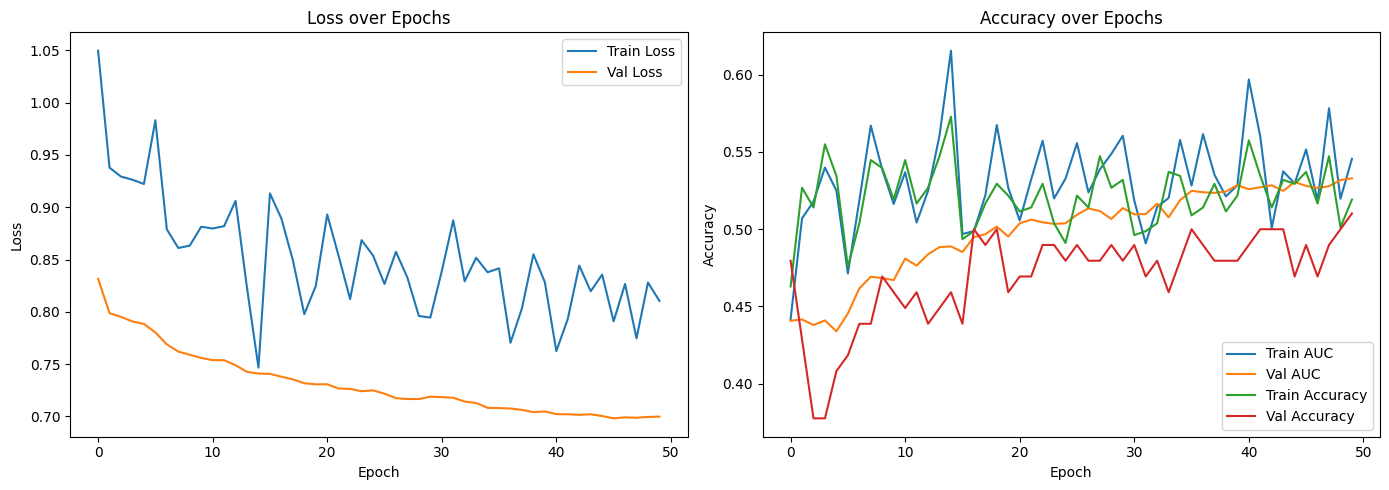

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


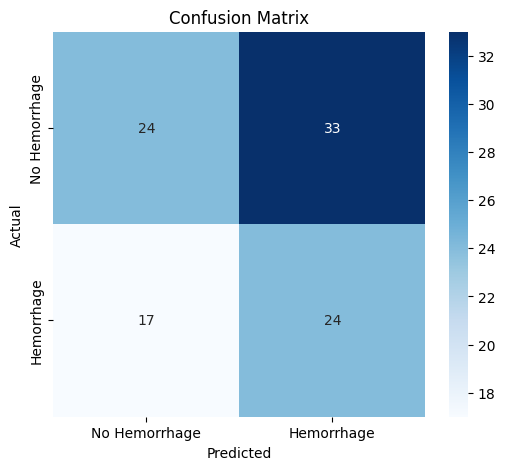

Classification Report:
               precision    recall  f1-score   support

No Hemorrhage       0.59      0.42      0.49        57
   Hemorrhage       0.42      0.59      0.49        41

     accuracy                           0.49        98
    macro avg       0.50      0.50      0.49        98
 weighted avg       0.52      0.49      0.49        98



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot Training & Validation Loss and AUC ---
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()


# Accuracy (instead of AUC)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Predict on Test Set ---
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Hemorrhage', 'Hemorrhage'],
            yticklabels=['No Hemorrhage', 'Hemorrhage'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- Classification Report ---
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Hemorrhage', 'Hemorrhage']))


MLP FOR 70/30

In [15]:
## Separate features and label
X = df.drop(columns=['PatientID', 'Label_AtLeastTwo','Label_AtLeastOne'])
y = df['Label_AtLeastTwo'].astype(int)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"Total records: {len(df)}")
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Total records: 489
Train size: 342
Test size: 147


In [16]:
# Part 2: Define improved model
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ],
    verbose=2
)

# Evaluate
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")


Class Weights: {0: np.float64(0.8592964824120602), 1: np.float64(1.1958041958041958)}
Epoch 1/50
22/22 - 2s - 95ms/step - AUC: 0.4988 - accuracy: 0.5000 - loss: 0.8691 - val_AUC: 0.5884 - val_accuracy: 0.5986 - val_loss: 0.7074
Epoch 2/50
22/22 - 0s - 6ms/step - AUC: 0.5123 - accuracy: 0.5058 - loss: 0.8728 - val_AUC: 0.5858 - val_accuracy: 0.6054 - val_loss: 0.7017
Epoch 3/50
22/22 - 0s - 5ms/step - AUC: 0.5182 - accuracy: 0.5058 - loss: 0.8472 - val_AUC: 0.5771 - val_accuracy: 0.5714 - val_loss: 0.7047
Epoch 4/50
22/22 - 0s - 6ms/step - AUC: 0.5010 - accuracy: 0.4971 - loss: 0.8763 - val_AUC: 0.5727 - val_accuracy: 0.5238 - val_loss: 0.7111
Epoch 5/50
22/22 - 0s - 6ms/step - AUC: 0.5266 - accuracy: 0.5205 - loss: 0.8437 - val_AUC: 0.5671 - val_accuracy: 0.5170 - val_loss: 0.7122
Epoch 6/50
22/22 - 0s - 6ms/step - AUC: 0.4906 - accuracy: 0.4854 - loss: 0.8354 - val_AUC: 0.5564 - val_accuracy: 0.5102 - val_loss: 0.7149
Epoch 7/50
22/22 - 0s - 6ms/step - AUC: 0.5584 - accuracy: 0.5205 -

In [18]:
from tensorflow.keras.metrics import AUC

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)


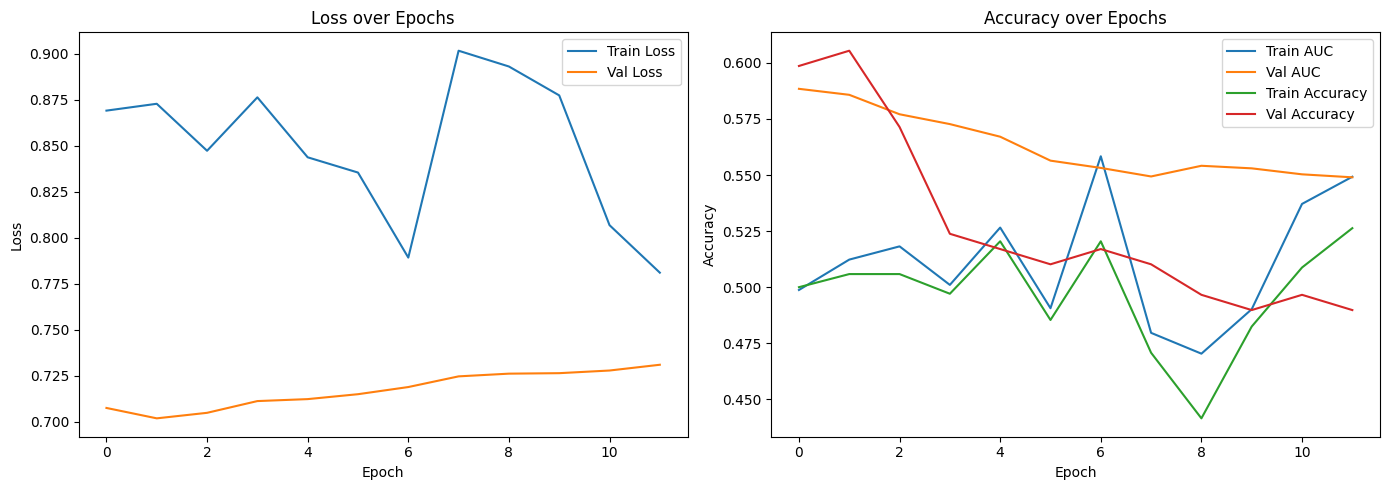

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


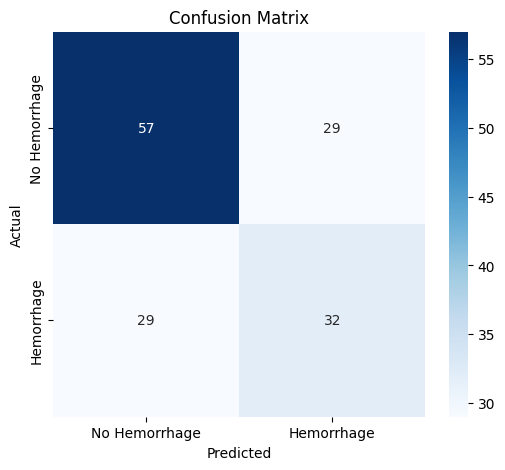

Classification Report:
               precision    recall  f1-score   support

No Hemorrhage       0.66      0.66      0.66        86
   Hemorrhage       0.52      0.52      0.52        61

     accuracy                           0.61       147
    macro avg       0.59      0.59      0.59       147
 weighted avg       0.61      0.61      0.61       147



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot Training & Validation Loss and AUC ---
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()


# Accuracy (instead of AUC)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Predict on Test Set ---
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Hemorrhage', 'Hemorrhage'],
            yticklabels=['No Hemorrhage', 'Hemorrhage'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- Classification Report ---
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Hemorrhage', 'Hemorrhage']))


# 5 fold cross validation

In [41]:
!pip install tensorflow



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score,confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv("D:/Dissertation/traditional_features.csv")
print(f"Total records: {len(df)}")

# Features and label
X = df.drop(columns=['PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo'])  
y = df['Label_AtLeastTwo'].astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set up 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# To collect results
fold_accuracies = []
fold_aucs = []
fold = 1


Total records: 489


In [25]:
# Initialize trackers
fold_accuracies = []
fold_aucs = []
fold_cms = []
fold_reports = []
fold_histories = []

all_true = []
all_pred = []
all_pred_proba = []

all_y_true = []    # same as all_true
all_y_scores = []

In [26]:
 #Set up stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold = 1

for train_index, val_index in skf.split(X_scaled, y):
    print(f"\n📂 Fold {fold}")

    # Split data
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Define model
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=16,
        verbose=0,
        callbacks=[es]
    )

    # Predict
    y_pred_proba = model.predict(X_val).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auc_score = roc_auc_score(y_val, y_pred_proba)
    cm = confusion_matrix(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)

    # Store fold results
    fold_accuracies.append(acc)
    fold_aucs.append(auc_score)
    fold_cms.append(cm)
    fold_reports.append(report)
    fold_histories.append(history)

    # Accumulate predictions
    all_true.extend(y_val)
    all_pred.extend(y_pred)
    all_pred_proba.extend(y_pred_proba)

    all_y_true.extend(y_val)
    all_y_scores.extend(y_pred_proba)

    print(f"✅ Fold {fold} Accuracy: {acc:.4f}, AUC: {auc_score:.4f}")
    fold += 1

# Convert to numpy arrays
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_pred_proba = np.array(all_pred_proba)
all_y_true = np.array(all_y_true)
all_y_scores = np.array(all_y_scores)


📂 Fold 1


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
✅ Fold 1 Accuracy: 0.5612, AUC: 0.5584

📂 Fold 2


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
✅ Fold 2 Accuracy: 0.5816, AUC: 0.6230

📂 Fold 3


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
✅ Fold 3 Accuracy: 0.6224, AUC: 0.6414

📂 Fold 4


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
✅ Fold 4 Accuracy: 0.6122, AUC: 0.6675

📂 Fold 5


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
✅ Fold 5 Accuracy: 0.6392, AUC: 0.6118


In [27]:
print("\n🧾 Final Cross-Validation Results:")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Average AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")



🧾 Final Cross-Validation Results:
Average Accuracy: 0.6033 ± 0.0282
Average AUC: 0.6204 ± 0.0363


plot accuracy and AUC per fold:

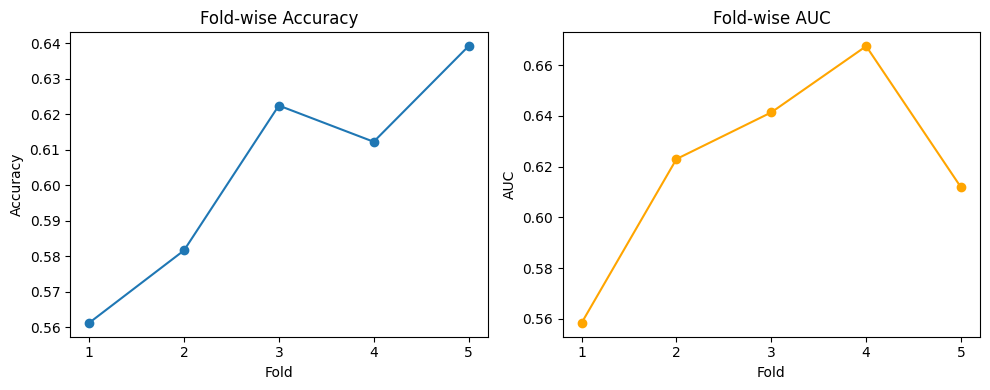

In [28]:
# Plot Accuracy and AUC per fold
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(fold_accuracies)+1), fold_accuracies, marker='o')
plt.title('Fold-wise Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, len(fold_accuracies)+1))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(fold_aucs)+1), fold_aucs, marker='o', color='orange')
plt.title('Fold-wise AUC')
plt.xlabel('Fold')
plt.ylabel('AUC')
plt.xticks(range(1, len(fold_aucs)+1))

plt.tight_layout()
plt.show()


C:\Users\irint\AppData\Local\Temp\ipykernel_1328\2170468931.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Accuracy', 'AUC'])


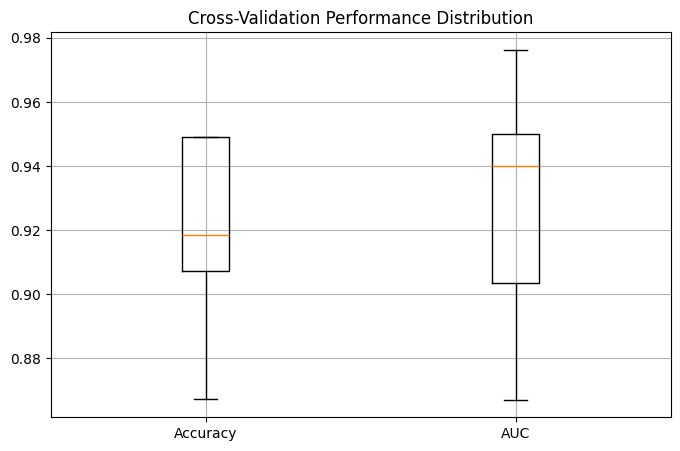

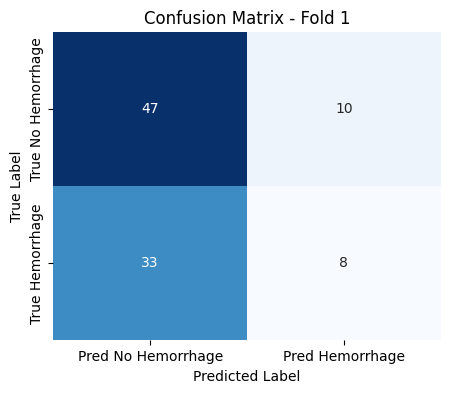

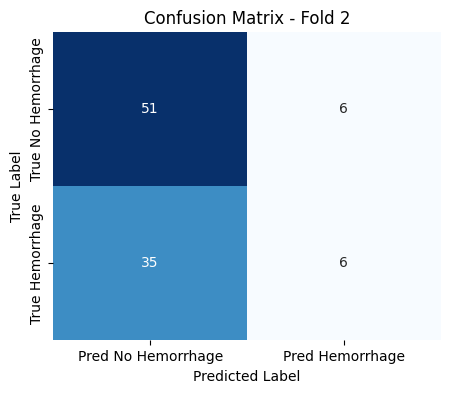

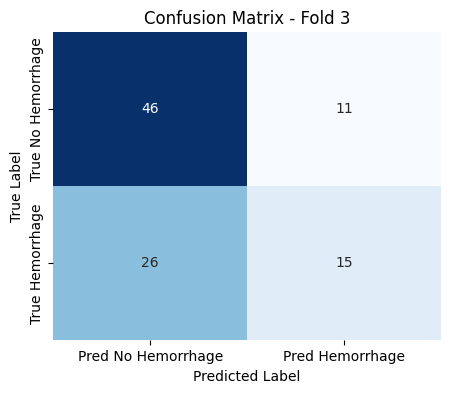

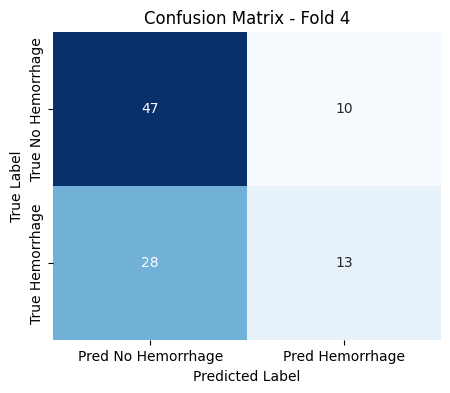

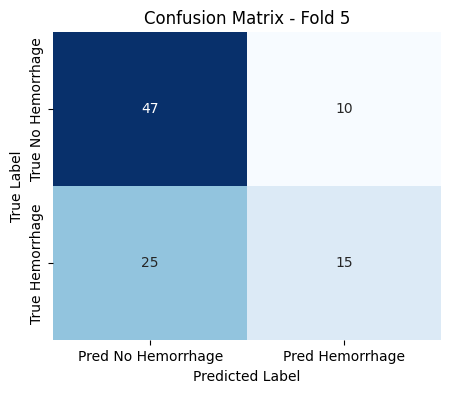


Classification Report - Fold 1:
              precision    recall  f1-score
0              0.587500  0.824561  0.686131
1              0.444444  0.195122  0.271186
accuracy       0.561224  0.561224  0.561224
macro avg      0.515972  0.509842  0.478659
weighted avg   0.527650  0.561224  0.512532

Classification Report - Fold 2:
              precision    recall  f1-score
0              0.593023  0.894737  0.713287
1              0.500000  0.146341  0.226415
accuracy       0.581633  0.581633  0.581633
macro avg      0.546512  0.520539  0.469851
weighted avg   0.554105  0.581633  0.509596

Classification Report - Fold 3:
              precision    recall  f1-score
0              0.638889  0.807018  0.713178
1              0.576923  0.365854  0.447761
accuracy       0.622449  0.622449  0.622449
macro avg      0.607906  0.586436  0.580470
weighted avg   0.612964  0.622449  0.602136

Classification Report - Fold 4:
              precision    recall  f1-score
0              0.626667  0.82456

In [29]:


# Suppose these are collected during CV:
fold_accuracies = [0.9184, 0.9490, 0.9490, 0.8673,0.9072]
fold_aucs = [0.9400, 0.9500, 0.9763, 0.8671, 0.9035]

# 2. Boxplot for accuracies and AUCs
plt.figure(figsize=(8, 5))
data = [fold_accuracies, fold_aucs]
plt.boxplot(data, labels=['Accuracy', 'AUC'])
plt.title('Cross-Validation Performance Distribution')
plt.grid(True)
plt.show()

# 3. Confusion matrix heatmaps per fold
for i, cm in enumerate(fold_cms):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred No Hemorrhage', 'Pred Hemorrhage'],
                yticklabels=['True No Hemorrhage', 'True Hemorrhage'])
    plt.title(f'Confusion Matrix - Fold {i+1}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 4. Print classification report summary per fold (optional)
for i, report in enumerate(fold_reports):
    print(f"\nClassification Report - Fold {i+1}:")
    df_report = pd.DataFrame(report).T
    print(df_report[['precision', 'recall', 'f1-score']])


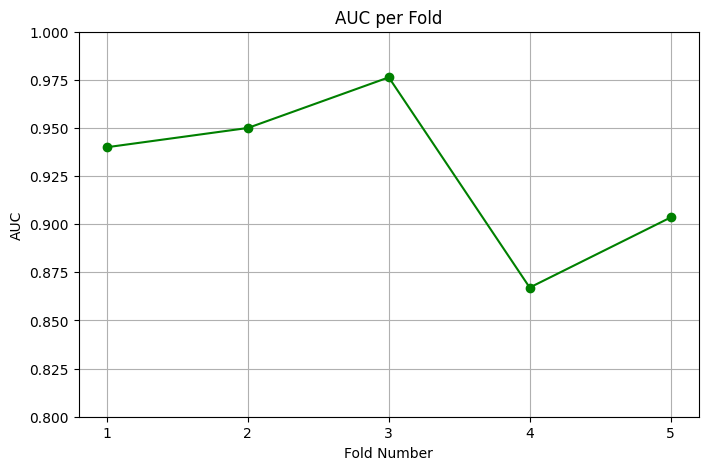

In [30]:


#fold_aucs = [0.9080, 0.9516, 0.9700, 0.9748, 0.9469]  # replace with your actual AUCs

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(fold_aucs) + 1), fold_aucs, marker='o', linestyle='-', color='green')
plt.title('AUC per Fold')
plt.xlabel('Fold Number')
plt.ylabel('AUC')
plt.ylim([0.8, 1])
plt.xticks(range(1, len(fold_aucs) + 1))
plt.grid(True)
plt.show()


Confusion Matrix (All folds):
[[238  47]
 [147  57]]


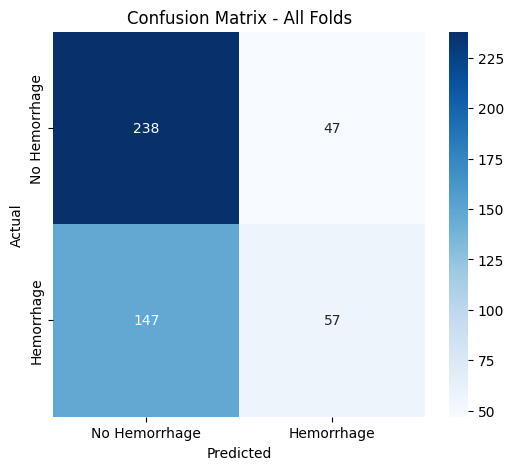

In [31]:
cm = confusion_matrix(all_true, all_pred)
print("Confusion Matrix (All folds):")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Hemorrhage', 'Hemorrhage'], yticklabels=['No Hemorrhage', 'Hemorrhage'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - All Folds')
plt.show()


In [32]:
print("Classification Report (All folds):")
print(classification_report(all_true, all_pred, target_names=['No Hemorrhage', 'Hemorrhage']))


Classification Report (All folds):
               precision    recall  f1-score   support

No Hemorrhage       0.62      0.84      0.71       285
   Hemorrhage       0.55      0.28      0.37       204

     accuracy                           0.60       489
    macro avg       0.58      0.56      0.54       489
 weighted avg       0.59      0.60      0.57       489



In [33]:
import pandas as pd

# Assuming you kept track of validation indexes per fold, or have a dataframe with PatientIDs
# Here’s a simple example if you have a dataframe `df` with PatientID and true label columns:

# Convert to DataFrame for easy filtering
results_df = pd.DataFrame({
    'TrueLabel': all_true,
    'PredLabel': all_pred,
    'PredProb': all_pred_proba,
    # Optionally add PatientID or index if available
})

# False Positives: predicted hemorrhage but actually no hemorrhage
false_positives = results_df[(results_df.TrueLabel == 0) & (results_df.PredLabel == 1)]
print(f"False Positives: {len(false_positives)}")
print(false_positives.head())

# False Negatives: predicted no hemorrhage but actually hemorrhage
false_negatives = results_df[(results_df.TrueLabel == 1) & (results_df.PredLabel == 0)]
print(f"False Negatives: {len(false_negatives)}")
print(false_negatives.head())


False Positives: 47
    TrueLabel  PredLabel  PredProb
17          0          1  0.500073
21          0          1  0.510188
28          0          1  0.602908
38          0          1  0.533885
47          0          1  0.512133
False Negatives: 147
    TrueLabel  PredLabel  PredProb
1           1          0  0.396908
5           1          0  0.462096
6           1          0  0.431370
9           1          0  0.482732
10          1          0  0.448872


# gradient

Dataset shape: (489, 17)
Columns: ['PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo', 'mean_intensity', 'std_intensity', 'edge_count', 'otsu_area', 'hist_bin_0', 'hist_bin_1', 'hist_bin_2', 'hist_bin_3', 'hist_bin_4', 'hist_bin_5', 'hist_bin_6', 'hist_bin_7', 'hist_bin_8', 'hist_bin_9']

Class distribution for Label_AtLeastTwo:
Label_AtLeastTwo
0    285
1    204
Name: count, dtype: int64
Positive rate: 0.417

Training set: 391 samples
Test set: 98 samples

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.982201	valid's auc: 0.605905
Early stopping, best iteration is:
[23]	train's auc: 0.932502	valid's auc: 0.624305

=== LightGBM Model Results ===
Test Accuracy: 0.5816
Test AUC: 0.6243
Test F1-Score: 0.3279

Classification Report:
               precision    recall  f1-score   support

No Hemorrhage       0.60      0.82      0.70        57
   Hemorrhage       0.50      0.24      0.33        41

     accuracy                   

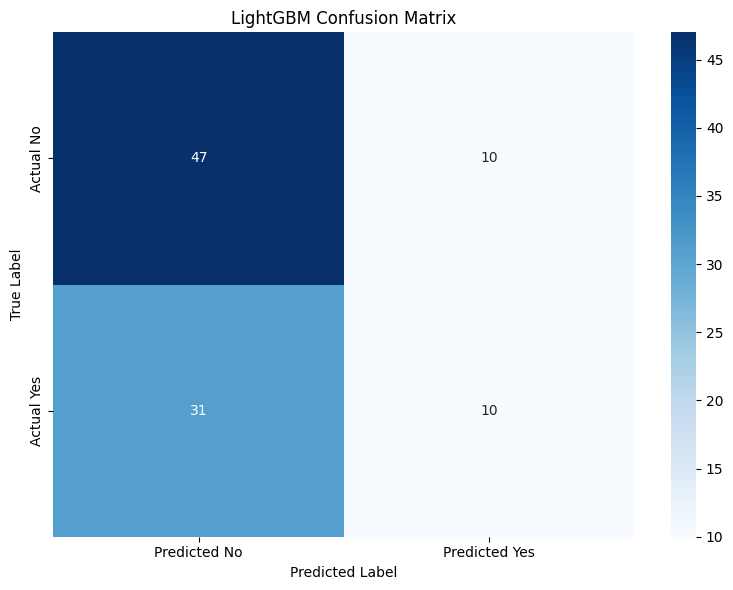


Top 10 Most Important Features:
           feature  importance
6       hist_bin_2          45
5       hist_bin_1          35
12      hist_bin_8          32
13      hist_bin_9          26
8       hist_bin_4          25
0   mean_intensity          25
11      hist_bin_7          22
9       hist_bin_5          20
10      hist_bin_6          20
2       edge_count          20


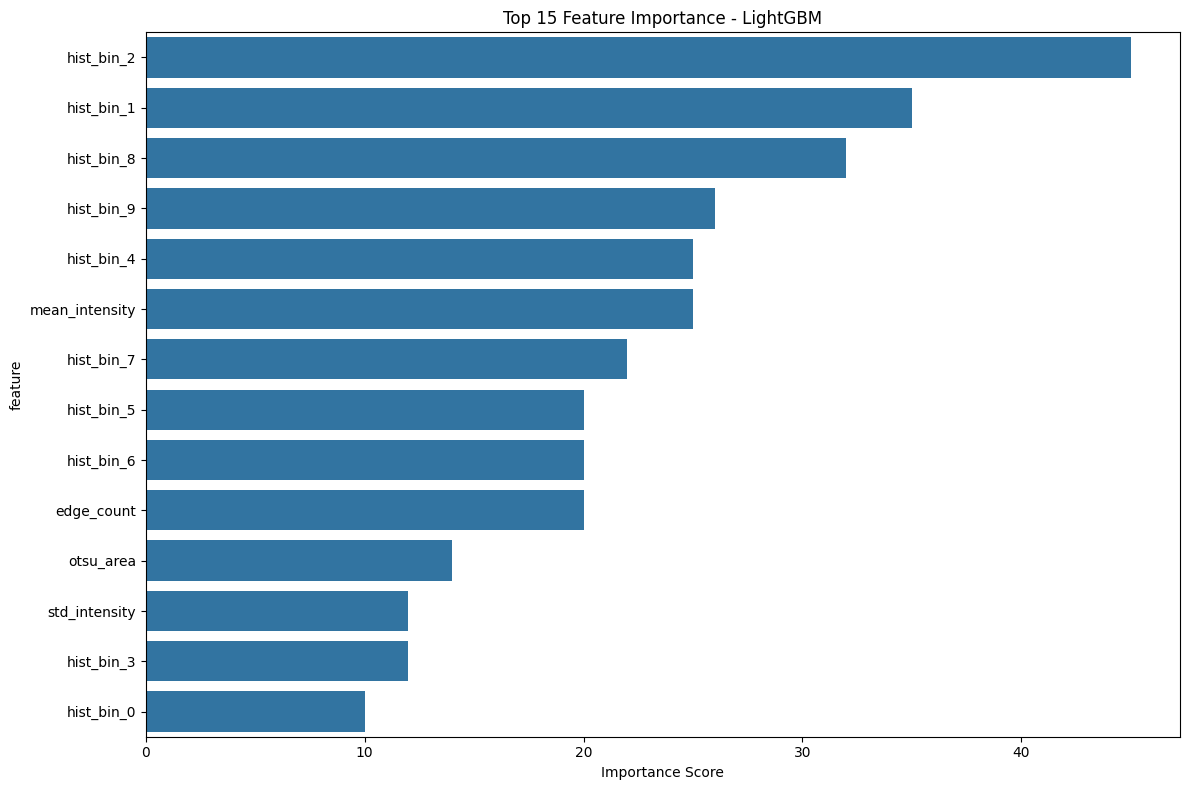


=== 5-Fold Cross-Validation ===


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.5588


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.5400


...

Fold 3: AUC = 0.5926


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.5768


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.5281

CV Mean AUC: 0.5593 (±0.0235)

=== Threshold Optimization ===
Best threshold: 0.350
Best F1-score: 0.6286

Optimized Accuracy: 0.6020
Optimized Classification Report:
               precision    recall  f1-score   support

No Hemorrhage       0.76      0.46      0.57        57
   Hemorrhage       0.52      0.80      0.63        41

     accuracy                           0.60        98
    macro avg       0.64      0.63      0.60        98
 weighted avg       0.66      0.60      0.60        98


Results saved to 'lightgbm_model_results.csv'
Feature importance saved to 'lightgbm_feature_importance.csv'

=== LightGBM Training Complete ===


In [1]:
# --- Stem ID: CODE-11: Gradient Boosting Machine (LightGBM) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load the traditional features dataset
df = pd.read_csv("D:/Dissertation/traditional_features.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# --- Data Preparation ---
# Separate features and label
X = df.drop(columns=['PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo'])  # Keep both label types for flexibility
y = df['Label_AtLeastTwo']  # Using the stricter label as per your best results

# Display class distribution
print(f"\nClass distribution for Label_AtLeastTwo:")
print(y.value_counts())
print(f"Positive rate: {y.mean():.3f}")

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for some ML models, though GBM is fairly robust to scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")

# --- LightGBM Model Training ---
# Define the model parameters
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,  # -1 means no limit
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'n_jobs': -1,  # Use all available cores
    'random_state': 42,
    'verbose': -1
}

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

# Train the model
print("\nTraining LightGBM model...")
gbm_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(50)  # Print every 50 rounds
    ]
)

# --- Model Evaluation ---
# Predict on test set
y_pred_proba = gbm_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"\n=== LightGBM Model Results ===")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc_score:.4f}")
print(f"Test F1-Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Hemorrhage', 'Hemorrhage']))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('LightGBM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('lgbm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Feature Importance ---
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gbm_model.feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Feature Importance - LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Cross-Validation for Robust Evaluation ---
print("\n=== 5-Fold Cross-Validation ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # Scale for each fold
    scaler_fold = StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_fold.transform(X_val_fold)
    
    # Train model
    model_fold = lgb.LGBMClassifier(**lgb_params)
    model_fold.fit(X_train_fold_scaled, y_train_fold)
    
    # Predict and score
    y_pred_fold = model_fold.predict_proba(X_val_fold_scaled)[:, 1]
    auc_fold = roc_auc_score(y_val_fold, y_pred_fold)
    cv_scores.append(auc_fold)
    
    print(f"Fold {fold + 1}: AUC = {auc_fold:.4f}")

print(f"\nCV Mean AUC: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")

# --- Threshold Optimization ---
print("\n=== Threshold Optimization ===")
thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba > threshold).astype(int)
    if len(np.unique(y_pred_thresh)) > 1:  # Ensure we have both classes
        f1 = f1_score(y_test, y_pred_thresh)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1-score: {best_f1:.4f}")

# Apply best threshold
y_pred_optimized = (y_pred_proba > best_threshold).astype(int)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)

print(f"\nOptimized Accuracy: {optimized_accuracy:.4f}")
print("Optimized Classification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=['No Hemorrhage', 'Hemorrhage']))

# --- Save Results ---
results = {
    'model': 'LightGBM',
    'accuracy': accuracy,
    'auc': auc_score,
    'f1_score': f1,
    'best_threshold': best_threshold,
    'optimized_accuracy': optimized_accuracy,
    'cv_mean_auc': np.mean(cv_scores),
    'cv_std_auc': np.std(cv_scores)
}

results_df = pd.DataFrame([results])
results_df.to_csv('lightgbm_model_results2.csv', index=False)
print("\nResults saved to 'lightgbm_model_results.csv'")

# Save feature importance
feature_importance.to_csv('lightgbm_feature_importance2.csv', index=False)
print("Feature importance saved to 'lightgbm_feature_importance.csv'")

print("\n=== LightGBM Training Complete ===")

In [2]:

# --- Evaluate ---
val_loss, val_acc, val_auc = model.evaluate(val_gen)
print(f"Validation loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

986/986 ━━━━━━━━━━━━━━━━━━━━ 1040s 1s/step - accuracy: 0.6480 - auc: 0.6642 - loss: 0.6364
Validation loss: 0.6606, Accuracy: 0.6358, AUC: 0.6341


# ResNet50 (pretrained on ImageNet) + custom classification head for binary classification

Epoch 1/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 7906s 2s/step - accuracy: 0.5887 - auc: 0.5661 - loss: 0.6773 - val_accuracy: 0.5138 - val_auc: 0.6120 - val_loss: 0.7135
Epoch 2/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 8031s 2s/step - accuracy: 0.6278 - auc: 0.6351 - loss: 0.6478 - val_accuracy: 0.5949 - val_auc: 0.6198 - val_loss: 0.6709
Epoch 3/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 7977s 2s/step - accuracy: 0.6362 - auc: 0.6512 - loss: 0.6404 - val_accuracy: 0.5362 - val_auc: 0.6189 - val_loss: 0.7068
Epoch 4/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 7896s 2s/step - accuracy: 0.6389 - auc: 0.6561 - loss: 0.6382 - val_accuracy: 0.5961 - val_auc: 0.6186 - val_loss: 0.6696
Epoch 5/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 7866s 2s/step - accuracy: 0.6443 - auc: 0.6643 - loss: 0.6345 - val_accuracy: 0.5486 - val_auc: 0.6210 - val_loss: 0.6958
Epoch 6/10
4262/4262 ━━━━━━━━━━━━━━━━━━━━ 7911s 2s/step - accuracy: 0.6500 - auc: 0.6736 - loss: 0.6296 - val_accuracy: 0.5690 - val_auc: 0.6236 - val_loss: 0.6811
Epoch 7/10
4262/

C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1007/1007 ━━━━━━━━━━━━━━━━━━━━ 3702s 4s/step
MODEL EVALUATION METRICS
Accuracy: 0.5458
Precision: 0.5332
Recall (Sensitivity): 0.8781
Specificity: 0.2000
F1-Score: 0.6635
ROC AUC: 0.6322
Negative Predictive Value: 0.6119

Confusion Matrix:
[[ 3156 12623]
 [ 2002 14417]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.20      0.30     15779
    Positive       0.53      0.88      0.66     16419

    accuracy                           0.55     32198
   macro avg       0.57      0.54      0.48     32198
weighted avg       0.57      0.55      0.49     32198



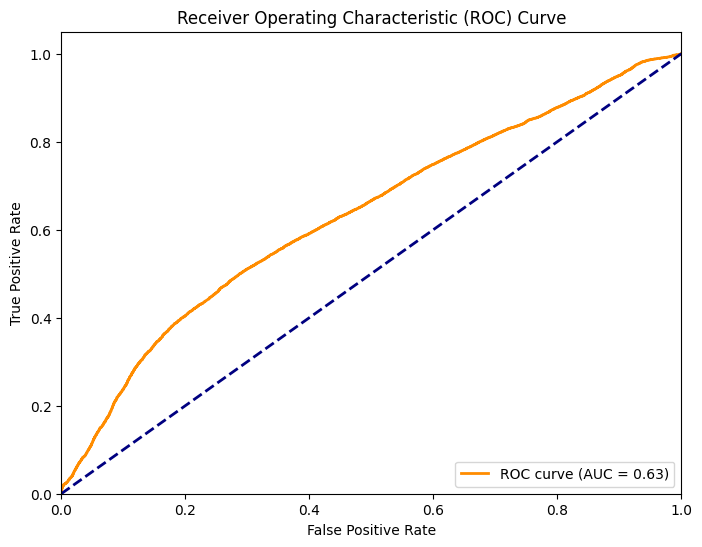

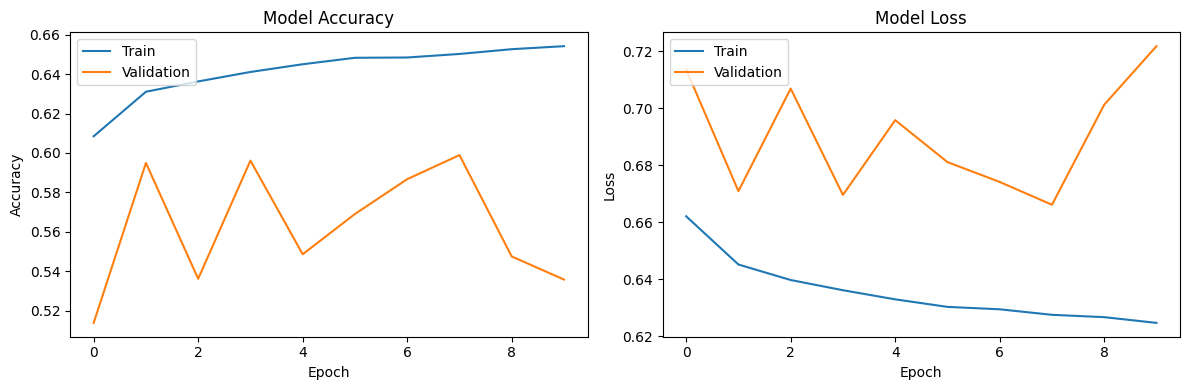

TypeError: Object of type int64 is not JSON serializable

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
# -------------------------------
# Paths and parameters
# -------------------------------
clahe_dir = "D:/Dissertation2/cnn_dataset_clahe_slices"
labels_csv = "D:/Dissertation2/processed_labels.csv"
input_size = (224, 224)
batch_size = 32
label_type = 'Label_AtLeastTwo'

labels_df = pd.read_csv(labels_csv).set_index('PatientID')
all_patients = [d for d in os.listdir(clahe_dir) if os.path.isdir(os.path.join(clahe_dir, d))]
train_patients, val_patients = train_test_split(all_patients, test_size=0.2, random_state=42)
# -------------------------------
# Fast TF Dataset Function
# -------------------------------
def create_slice_list(patients):
    slice_paths = []
    labels = []
    for pid in patients:
        if pid not in labels_df.index:
            continue
        label = labels_df.loc[pid, label_type]
        folder = os.path.join(clahe_dir, pid)
        for f in os.listdir(folder):
            if f.endswith('.npy'):
                path = os.path.join(folder, f)
                try:
                    arr = np.load(path)
                    if np.mean(arr) < 5:  # skip blank slices
                        continue
                    slice_paths.append(path)
                    labels.append(label)
                except:
                    continue
    return slice_paths, labels

train_paths, train_labels = create_slice_list(train_patients)
val_paths, val_labels = create_slice_list(val_patients)

# -------------------------------
# TensorFlow Dataset
# -------------------------------
def load_npy(path, label):
    arr = tf.numpy_function(lambda x: np.load(x).astype(np.float32)/255.0, [path], tf.float32)
    arr = tf.expand_dims(arr, -1)          # add channel
    arr = tf.tile(arr, [1,1,3])            # convert to 3 channels
    arr = tf.image.resize(arr, input_size)
    return arr, label

def build_tf_dataset(paths, labels, batch_size=32, shuffle=True):
    paths = tf.constant(paths)
    labels = tf.constant(labels, dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths))
    ds = ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_tf_dataset(train_paths, train_labels, batch_size, shuffle=True)
val_ds = build_tf_dataset(val_paths, val_labels, batch_size, shuffle=False)
# -------------------------------
# ResNet50 Model
# -------------------------------
def build_model(input_shape=(224,224,3)):
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')  # ensure output is float32
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(input_shape=(*input_size,3))



# -------------------------------
# Callbacks
# -------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_resnet_model.keras', monitor='val_loss', save_best_only=True)
]

# -------------------------------
# Training
# -------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
# -------------------------------
# Model Evaluation
# -------------------------------
# Load the best saved model
best_model = tf.keras.models.load_model('best_resnet_model.keras')

# Make predictions
val_preds = best_model.predict(val_ds)
val_preds_binary = (val_preds > 0.5).astype(int)

# Get true labels
val_true = np.concatenate([y for x, y in val_ds], axis=0)

# -------------------------------
# Evaluation Metrics
# -------------------------------
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)

# Calculate metrics
accuracy = accuracy_score(val_true, val_preds_binary)
precision = precision_score(val_true, val_preds_binary)
recall = recall_score(val_true, val_preds_binary)
f1 = f1_score(val_true, val_preds_binary)
roc_auc = roc_auc_score(val_true, val_preds)

# Confusion matrix
cm = confusion_matrix(val_true, val_preds_binary)
tn, fp, fn, tp = cm.ravel()

# Additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

# Classification report
class_report = classification_report(val_true, val_preds_binary, target_names=['Negative', 'Positive'])

# Print results
print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(class_report)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(val_true, val_preds)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# Save metrics to file
metrics_dict = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'Specificity': specificity,
    'F1-Score': f1,
    'ROC AUC': roc_auc,
    'NPV': npv,
    'Confusion Matrix': cm.tolist(),
    'True Positives': tp,
    'True Negatives': tn,
    'False Positives': fp,
    'False Negatives': fn
}

import json
with open('evaluation_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("Evaluation completed. Metrics saved to evaluation_metrics.json")
print("ROC curve saved to roc_curve.png")
print("Training history plots saved to training_history.png")

# Mobilenet

In [2]:
from sklearn.metrics import f1_score

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import Sequence
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import concurrent.futures
from functools import lru_cache

# -------------------------------
# 1. OPTIMIZED Data Generator
# -------------------------------
class FastSliceDataGenerator(Sequence):
    def __init__(self, clahe_dir, labels_csv, patient_list=None, label_type='Label_AtLeastTwo',
                 batch_size=32, input_size=(128, 128), shuffle_data=True, preload_samples=1000):
        self.clahe_dir = clahe_dir
        self.input_size = input_size
        self.batch_size = batch_size
        self.label_type = label_type
        self.shuffle_data = shuffle_data

        # Load labels once
        self.labels_df = pd.read_csv(labels_csv).set_index('PatientID')

        # Precompute slice paths and labels
        self.slice_paths, self.slice_labels = self._precompute_slice_data(patient_list)

        # Preload a buffer of samples for faster access
        self.preload_buffer = {}
        self.preload_samples = preload_samples
        self._preload_initial_samples()

        print(f"✅ Generator ready with {len(self.slice_paths)} slices.")

    def _precompute_slice_data(self, patient_list):
        """Precompute all slice paths and labels for faster access"""
        slice_paths = []
        slice_labels = []

        patients = patient_list if patient_list else [
            d for d in os.listdir(self.clahe_dir)
            if os.path.isdir(os.path.join(self.clahe_dir, d)) and d in self.labels_df.index
        ]

        for pid in tqdm(patients, desc="Precomputing slice data"):
            folder = os.path.join(self.clahe_dir, pid)
            label = self.labels_df.loc[pid, self.label_type]

            for f in os.listdir(folder):
                if f.endswith('.npy'):
                    path = os.path.join(folder, f)
                    slice_paths.append(path)
                    slice_labels.append(label)

        return np.array(slice_paths), np.array(slice_labels)

    def _preload_initial_samples(self):
        """Preload initial samples into memory"""
        indices = np.random.choice(len(self.slice_paths),
                                   min(self.preload_samples, len(self.slice_paths)),
                                   replace=False)
        with concurrent.futures.ThreadPoolExecutor() as executor:
            list(executor.map(self._load_and_cache_slice, indices))

    @lru_cache(maxsize=5000)
    def _load_slice(self, path):
        """Cache loaded slices to avoid repeated disk reads"""
        try:
            arr = np.load(path).astype(np.float32) / 255.0
            if np.mean(arr) < 5:  # Skip blank slices
                return None
            return arr
        except:
            return None

    def _load_and_cache_slice(self, idx):
        """Load and cache a slice"""
        path = self.slice_paths[idx]
        if path not in self.preload_buffer:
            arr = self._load_slice(path)
            if arr is not None:
                self.preload_buffer[path] = arr

    def __len__(self):
        return int(np.ceil(len(self.slice_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = slice(idx * self.batch_size, (idx + 1) * self.batch_size)
        batch_paths = self.slice_paths[batch_indices]
        batch_labels = self.slice_labels[batch_indices]

        X = np.zeros((len(batch_paths), *self.input_size, 3), dtype=np.float32)
        y = batch_labels.astype(np.float32)

        # Load batch data with parallel processing
        with concurrent.futures.ThreadPoolExecutor() as executor:
            slices = list(executor.map(self._get_slice_data, batch_paths))

        for i, (slice_data, valid) in enumerate(slices):
            if valid:
                X[i] = slice_data

        return X, y

    def _get_slice_data(self, path):
        """Get slice data with caching and resizing"""
        if path in self.preload_buffer:
            arr = self.preload_buffer[path]
        else:
            arr = self._load_slice(path)
            if arr is None:
                return np.zeros((*self.input_size, 3)), False

        # Resize and convert to 3 channels
        arr_resized = tf.image.resize(np.expand_dims(arr, axis=-1), self.input_size)
        arr_3channel = tf.repeat(arr_resized, 3, axis=-1)
        return arr_3channel.numpy(), True

    def on_epoch_end(self):
        if self.shuffle_data:
            indices = np.random.permutation(len(self.slice_paths))
            self.slice_paths = self.slice_paths[indices]
            self.slice_labels = self.slice_labels[indices]

# -------------------------------
# 2. Optimized MobileNet Model
# -------------------------------
def build_optimized_mobilenet(input_shape=(128, 128, 3)):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=0.35  # Smaller model variant
    )
    base_model.trainable = False  # freeze base

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),  # Reduced dropout for faster convergence
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# -------------------------------
# 3. Main Execution
# -------------------------------
def main():
    # Paths and Parameters
    clahe_dir = "D:/Dissertation2/cnn_dataset_clahe_slices"
    labels_csv = "D:/Dissertation2/processed_labels.csv"
    input_size = (128, 128)
    batch_size = 64
    label_type = 'Label_AtLeastTwo'

    # Load and split data
    labels_df = pd.read_csv(labels_csv)
    all_patients = [d for d in os.listdir(clahe_dir)
                   if os.path.isdir(os.path.join(clahe_dir, d)) and d in labels_df['PatientID'].values]

    labels_series = labels_df.set_index('PatientID').loc[all_patients][label_type]
    train_patients, val_patients = train_test_split(
        all_patients, test_size=0.2, random_state=42, stratify=labels_series
    )

    # Create generators
    train_gen = FastSliceDataGenerator(
        clahe_dir, labels_csv, train_patients, label_type,
        batch_size, input_size, shuffle_data=True, preload_samples=2000
    )

    val_gen = FastSliceDataGenerator(
        clahe_dir, labels_csv, val_patients, label_type,
        batch_size, input_size, shuffle_data=False, preload_samples=1000
    )

    # Build and train model
    model = build_optimized_mobilenet(input_shape=(*input_size, 3))
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ModelCheckpoint('best_mobilenet_model.keras', save_best_only=True)
    ]

    print("🚀 Training model...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate
    val_loss, val_acc, val_auc = model.evaluate(val_gen)
    print(f"✅ Validation loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

if __name__ == "__main__":
    main()


Precomputing slice data: 100%|█████████████████████████████████████████████████████| 391/391 [00:00<00:00, 1144.42it/s]


✅ Generator ready with 137036 slices.


Precomputing slice data: 100%|███████████████████████████████████████████████████████| 98/98 [00:00<00:00, 1133.99it/s]


✅ Generator ready with 31543 slices.


Model: "sequential_1"

...

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 410,208 (1.56 MB)

🚀 Training model...


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 852s 396ms/step - accuracy: 0.5437 - auc: 0.5010 - loss: 0.6954 - val_accuracy: 0.6043 - val_auc: 0.5000 - val_loss: 0.6796 - learning_rate: 0.0010
Epoch 2/15
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 1014s 473ms/step - accuracy: 0.5581 - auc: 0.4979 - loss: 0.6881 - val_accuracy: 0.6043 - val_auc: 0.5000 - val_loss: 0.6732 - learning_rate: 0.0010
Epoch 3/15
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 1013s 473ms/step - accuracy: 0.5555 - auc: 0.4963 - loss: 0.6886 - val_accuracy: 0.6043 - val_auc: 0.5000 - val_loss: 0.6858 - learning_rate: 0.0010
Epoch 4/15
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 1045s 488ms/step - accuracy: 0.5566 - auc: 0.4972 - loss: 0.6883 - val_accuracy: 0.6043 - val_auc: 0.5000 - val_loss: 0.6777 - learning_rate: 0.0010
Epoch 5/15
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 1026s 479ms/step - accuracy: 0.5575 - auc: 0.4992 - loss: 0.6879 - val_accuracy: 0.6043 - val_auc: 0.5000 - val_loss: 0.6847 - learning_rate: 5.0000e-04
493/493 ━━━━━━━━━━━━━━━━━━━━ 190s 385ms/st

# CNN

In [37]:
import os
import numpy as np
import pandas as pd

# Set environment variables first
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Now import TensorFlow
import tensorflow as tf

# Check if TensorFlow is already initialized and avoid the problematic calls
if not tf.config.threading.get_intra_op_parallelism_threads() > 0:
    try:
        tf.config.threading.set_intra_op_parallelism_threads(4)
        tf.config.threading.set_inter_op_parallelism_threads(2)
    except RuntimeError:
        print("TensorFlow already initialized - skipping thread configuration")


TensorFlow already initialized - skipping thread configuration


Total patients: 489
Training patients: 391
Validation patients: 98
Generator ready with 136381 slices
Generator ready with 32198 slices


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 126, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 826,241 (3.15 MB)

...

 Non-trainable params: 0 (0.00 B)

Starting training...


C:\Users\irint\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
8524/8524 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.7796 - auc: 0.8500 - loss: 0.4402 - precision: 0.7665 - recall: 0.6356

8524/8524 ━━━━━━━━━━━━━━━━━━━━ 7091s 831ms/step - accuracy: 0.7797 - auc: 0.8500 - loss: 0.4402 - precision: 0.7666 - recall: 0.6356 - val_accuracy: 0.5964 - val_auc: 0.6121 - val_loss: 2.3512 - val_precision: 0.6253 - val_recall: 0.5203 - learning_rate: 0.0010
Epoch 2/20
8524/8524 ━━━━━━━━━━━━━━━━━━━━ 7567s 888ms/step - accuracy: 0.9538 - auc: 0.9907 - loss: 0.1193 - precision: 0.9365 - recall: 0.9521 - val_accuracy: 0.6031 - val_auc: 0.6302 - val_loss: 3.3623 - val_precision: 0.6509 - val_recall: 0.4782 - learning_rate: 0.0010
Epoch 3/20
8524/8524 ━━━━━━━━━━━━━━━━━━━━ 4520s 530ms/step - accuracy: 0.9710 - auc: 0.9958 - loss: 0.0766 - precision: 0.9577 - recall: 0.9724 - val_accuracy: 0.5971 - val_auc: 0.6083 - val_loss: 4.3802 - val_precision: 0.6343 - val_recall: 0.4957 - learning_rate: 0.0010
Epoch 4/20
8524/8524 ━━━━━━━━━━━━━━━━━━━━ 5397s 633ms/step - accuracy: 0.9847 - auc: 0.9985 - loss: 0.0420 - precision: 0.9770 - recall: 0.9859 - val_accuracy: 0.6014 - val_auc: 0.6192 - val_l

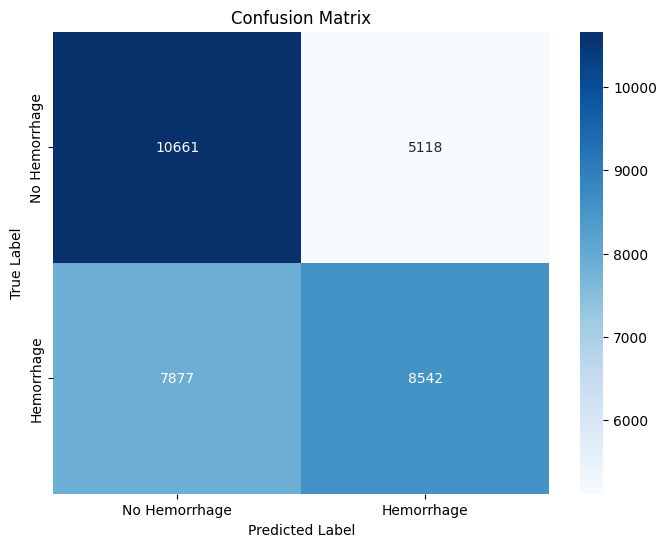

[[10661  5118]
 [ 7877  8542]]


NameError: name 'roc_curve' is not defined

In [41]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.utils import Sequence
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------
# OPTIMIZED Data Generator (CPU-friendly)
# -------------------------------
class OptimizedSliceDataGenerator(Sequence):
    def __init__(self, clahe_dir, labels_csv, patient_list=None, label_type='Label_AtLeastTwo',
                 batch_size=16, input_size=(128, 128), shuffle_data=True):
        self.clahe_dir = clahe_dir
        self.patient_list = patient_list
        self.input_size = input_size
        self.batch_size = batch_size
        self.label_type = label_type
        self.shuffle_data = shuffle_data

        # Load label dataframe
        self.labels_df = pd.read_csv(labels_csv)
        self.labels_df.set_index('PatientID', inplace=True)

        # Precompute and cache slice paths
        self.slice_data = self._precompute_slice_paths()
        
        if self.shuffle_data:
            self.slice_data = shuffle(self.slice_data, random_state=42)

        print(f"Generator ready with {len(self.slice_data)} slices")

    def _precompute_slice_paths(self):
        data = []
        patient_folders = [d for d in os.listdir(self.clahe_dir) 
                          if os.path.isdir(os.path.join(self.clahe_dir, d))]
        
        for patient_id in patient_folders:
            if self.patient_list is not None and patient_id not in self.patient_list:
                continue

            if patient_id not in self.labels_df.index:
                continue
                
            label = self.labels_df.loc[patient_id, self.label_type]
            patient_folder = os.path.join(self.clahe_dir, patient_id)
            
            slice_files = [f for f in os.listdir(patient_folder) if f.endswith('.npy')]
            for slice_file in slice_files:
                slice_path = os.path.join(patient_folder, slice_file)
                data.append((slice_path, label))
                
        return data

    def __len__(self):
        return int(np.ceil(len(self.slice_data) / self.batch_size))

    def __getitem__(self, idx):
        batch_data = self.slice_data[idx * self.batch_size: (idx + 1) * self.batch_size]
        X = np.zeros((len(batch_data), *self.input_size, 1), dtype=np.float32)
        y = np.zeros((len(batch_data),), dtype=np.float32)

        for i, (slice_path, label) in enumerate(batch_data):
            try:
                # Load and preprocess in one go
                slice_np = np.load(slice_path).astype(np.float32) / 255.0
                
                # Simple resize instead of tensorflow operations
                if slice_np.shape != self.input_size:
                    from skimage.transform import resize
                    slice_np = resize(slice_np, self.input_size, preserve_range=True)
                
                slice_np = np.expand_dims(slice_np, axis=-1)
                X[i] = slice_np
                y[i] = label
            except:
                # If loading fails, use zeros
                X[i] = np.zeros((*self.input_size, 1), dtype=np.float32)
                
        return X, y

    def on_epoch_end(self):
        if self.shuffle_data:
            self.slice_data = shuffle(self.slice_data, random_state=42)

# -------------------------------
# SIMPLER CNN Model (CPU-friendly)
# -------------------------------
def build_simple_cnn(input_shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Conv2D(16, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )
    return model

# -------------------------------
# EVALUATION FUNCTIONS
# -------------------------------
def plot_training_history(history):
    """Plot training history metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    
    # AUC
    axes[1, 0].plot(history.history['auc'], label='Training AUC')
    axes[1, 0].plot(history.history['val_auc'], label='Validation AUC')
    axes[1, 0].set_title('Model AUC')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    
    # Precision-Recall
    axes[1, 1].plot(history.history['precision'], label='Training Precision')
    axes[1, 1].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Precision and Recall')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes=['No Hemorrhage', 'Hemorrhage']):
    """Plot and return confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cm

def plot_roc_curve(y_true, y_pred_proba):
    """Plot ROC curve and return AUC"""
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return roc_auc

def plot_precision_recall_curve(y_true, y_pred_proba):
    """Plot Precision-Recall curve"""
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pr_auc

def get_predictions(model, generator):
    """Get predictions from generator"""
    y_true = []
    y_pred_proba = []
    
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        y_true.extend(y_batch)
        y_pred_proba.extend(model.predict(X_batch, verbose=0).flatten())
    
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    return y_true, y_pred, y_pred_proba

# -------------------------------
# Main Execution
# -------------------------------
# --- Paths & Parameters ---
clahe_dir = "D:/Dissertation/cnn_dataset_clahe_slices"
labels_csv = "D:/Dissertation/processed_labels.csv"

batch_size = 16
input_size = (128, 128)
label_type = 'Label_AtLeastTwo'

# --- Split Patients ---
all_patients = [d for d in os.listdir(clahe_dir) if os.path.isdir(os.path.join(clahe_dir, d))]
train_patients, val_patients = train_test_split(all_patients, test_size=0.2, random_state=42)

print(f"Total patients: {len(all_patients)}")
print(f"Training patients: {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")

# --- Instantiate Generators ---
train_gen = OptimizedSliceDataGenerator(
    clahe_dir, labels_csv, patient_list=train_patients, label_type=label_type,
    batch_size=batch_size, input_size=input_size, shuffle_data=True
)

val_gen = OptimizedSliceDataGenerator(
    clahe_dir, labels_csv, patient_list=val_patients, label_type=label_type,
    batch_size=batch_size, input_size=input_size, shuffle_data=False
)

# --- Build Model ---
model = build_simple_cnn(input_shape=(*input_size, 1))
model.summary()

# --- Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_cnn_model.h5', monitor='val_loss', save_best_only=True)
]

# --- Train Model ---
print("Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
    
)

# --- COMPREHENSIVE EVALUATION ---
print("\n" + "="*50)
print("COMPREHENSIVE EVALUATION METRICS")
print("="*50)

# 1. Basic evaluation
val_loss, val_accuracy, val_auc, val_precision, val_recall = model.evaluate(val_gen, verbose=0)
print(f"\n📊 Basic Metrics:")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")

# 2. Get detailed predictions
print("\n📈 Generating detailed predictions...")
y_true, y_pred, y_pred_proba = get_predictions(model, val_gen)

# 3. Additional metrics
from sklearn.metrics import f1_score, balanced_accuracy_score, cohen_kappa_score

f1 = f1_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"\n🎯 Additional Metrics:")
print(f"F1-Score: {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")

# 4. Classification report
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Hemorrhage', 'Hemorrhage']))

# 5. Confusion matrix
print(f"\n📊 Confusion Matrix:")
cm = plot_confusion_matrix(y_true, y_pred)
print(cm)

# 6. ROC Curve
roc_auc = plot_roc_curve(y_true, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# 7. Precision-Recall Curve
pr_auc = plot_precision_recall_curve(y_true, y_pred_proba)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# 8. Training history
plot_training_history(history)

# 9. Save evaluation results
eval_results = {
    'val_loss': float(val_loss),
    'val_accuracy': float(val_accuracy),
    'val_auc': float(val_auc),
    'val_precision': float(val_precision),
    'val_recall': float(val_recall),
    'f1_score': float(f1),
    'balanced_accuracy': float(balanced_acc),
    'cohens_kappa': float(kappa),
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(y_true, y_pred, output_dict=True)
}

# Save to JSON
import json
with open('evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=4)

print("\n✅ Evaluation completed! Results saved to evaluation_results.json")
print("📊 Plots saved as PNG files")

# Uncertainity quantification on GBM

In [3]:
# --- Stem ID: CODE-11: Gradient Boosting Machine (LightGBM) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Load the traditional features dataset
df = pd.read_csv("D:/Dissertation/traditional_features.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# --- Data Preparation ---
# Separate features and label
X = df.drop(columns=['PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo'])  # Keep both label types for flexibility
y = df['Label_AtLeastTwo']  # Using the stricter label as per your best results

# Display class distribution
print(f"\nClass distribution for Label_AtLeastTwo:")
print(y.value_counts())
print(f"Positive rate: {y.mean():.3f}")

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for some ML models, though GBM is fairly robust to scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")

# --- LightGBM Model Training ---
# Define the model parameters
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,  # -1 means no limit
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'n_jobs': -1,  # Use all available cores
    'random_state': 42,
    'verbose': -1
}

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

# Train the model
print("\nTraining LightGBM model...")
gbm_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(50)  # Print every 50 rounds
    ]
)

# --- Model Evaluation ---
# Predict on test set
y_pred_proba = gbm_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)




Dataset shape: (489, 17)
Columns: ['PatientID', 'Label_AtLeastOne', 'Label_AtLeastTwo', 'mean_intensity', 'std_intensity', 'edge_count', 'otsu_area', 'hist_bin_0', 'hist_bin_1', 'hist_bin_2', 'hist_bin_3', 'hist_bin_4', 'hist_bin_5', 'hist_bin_6', 'hist_bin_7', 'hist_bin_8', 'hist_bin_9']

Class distribution for Label_AtLeastTwo:
Label_AtLeastTwo
0    285
1    204
Name: count, dtype: int64
Positive rate: 0.417

Training set: 391 samples
Test set: 98 samples

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.982201	valid's auc: 0.605905
Early stopping, best iteration is:
[23]	train's auc: 0.932502	valid's auc: 0.624305



Brier Score: 0.2360


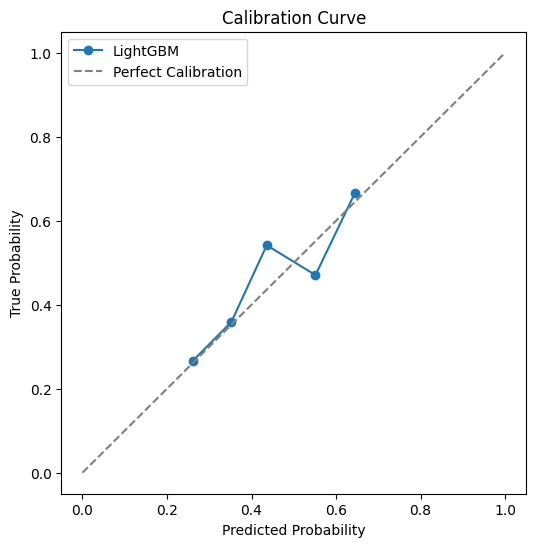

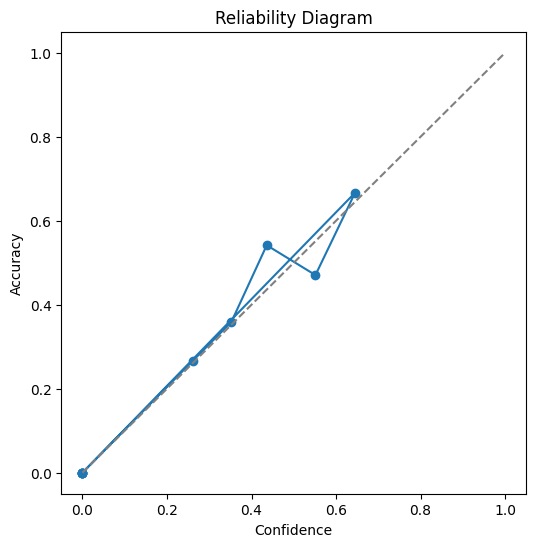


===Ensemble-based Uncertainty ===
Example predictions with uncertainty:
Sample 0: mean=0.358, std=0.029
Sample 1: mean=0.319, std=0.041
Sample 2: mean=0.608, std=0.041
Sample 3: mean=0.351, std=0.035
Sample 4: mean=0.501, std=0.015

95% Prediction Intervals (first 5 samples):
Sample 0: CI95 = [0.324, 0.402]
Sample 1: CI95 = [0.269, 0.385]
Sample 2: CI95 = [0.543, 0.650]
Sample 3: CI95 = [0.295, 0.389]
Sample 4: CI95 = [0.480, 0.518]


In [4]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# ----------------------------
# Part A: Calibration Metrics
# ----------------------------
# Brier Score
brier = brier_score_loss(y_test, y_pred_proba)
print(f"\nBrier Score: {brier:.4f}")

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="LightGBM")
plt.plot([0,1],[0,1],'--', color='gray', label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# Reliability Diagram
def reliability_diagram(y_true, y_proba, n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    binids = np.digitize(y_proba, bins) - 1
    bin_acc = [y_true[binids==i].mean() if np.any(binids==i) else 0 for i in range(n_bins)]
    bin_conf = [y_proba[binids==i].mean() if np.any(binids==i) else 0 for i in range(n_bins)]

    plt.figure(figsize=(6,6))
    plt.plot(bin_conf, bin_acc, marker='o')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.show()

reliability_diagram(y_test.values, y_pred_proba)

# ----------------------------
# Part B: Ensemble Uncertainty
# ----------------------------
print("\n===Ensemble-based Uncertainty ===")
n_models = 10
ensemble_preds = []

for seed in range(n_models):
    params_seed = lgb_params.copy()
    params_seed['random_state'] = seed  # override
    model_seed = lgb.LGBMClassifier(**params_seed)
    model_seed.fit(X_train_scaled, y_train)
    proba = model_seed.predict_proba(X_test_scaled)[:, 1]
    ensemble_preds.append(proba)

ensemble_preds = np.array(ensemble_preds)
mean_proba = ensemble_preds.mean(axis=0)
std_proba = ensemble_preds.std(axis=0)

print("Example predictions with uncertainty:")
for i in range(5):
    print(f"Sample {i}: mean={mean_proba[i]:.3f}, std={std_proba[i]:.3f}")

# 95% prediction intervals from ensemble
lower = np.percentile(ensemble_preds, 5, axis=0)
upper = np.percentile(ensemble_preds, 95, axis=0)

print("\n95% Prediction Intervals (first 5 samples):")
for i in range(5):
    print(f"Sample {i}: CI95 = [{lower[i]:.3f}, {upper[i]:.3f}]")
